# Kumo Tabular vs Jev vs the trees

[Kumo Tabular](https://huggingface.co/nvidia/Kumo-Tabular) is NVIDIA's tabular foundation model, released September 2026. It sits between the two approaches compared so far:

| | Sees our labels? | Trained on our data? | Input |
|---|---|---|---|
| LightGBM / XGBoost / random forest | yes | yes, fitted on `train` | the feature columns |
| **Kumo Tabular** | **yes, as context** | **no, no weights change** | **the same feature columns** |
| Jev | no, zero-shot | no | a text description of each row |

Kumo is given the labelled `train` rows as *context*, alongside the rows to score, and predicts their labels in one forward pass, the way an LLM answers from examples in its prompt. It was pretrained only on synthetic tables. It sees exactly the columns the trees see (one `FeatureSpec`), so any difference is the model.

The code is in `baby_ml/kumo.py`. It needs the opt-in dependency group, and the weights (110 MB for `small`) download from Hugging Face on first use:

```bash
uv sync --group ml --group kumo
```

**Two stages, as before:**
1. **`val`:** Kumo next to all three trees and all four Jev layouts, the same rows as `03_jev_layouts`.
2. **`test`:** Kumo added to the `04_test_comparison` line-up. Its settings are fixed up front (defaults: `small`, 1 ensemble member; 4 crashed this 16 GB laptop mid-fit) and not changed after seeing `test`. As with XGBoost it's scored two ways, and the context is Kumo's counterpart of a refit:
   - `kumo_small`: context = `train`, like for like with `xgboost`.
   - `kumo_small_train_val`: context = `train` + `val`, like for like with `xgboost_train_val`. Given how much recency mattered in `04`, this is the one to watch.

**Runtime and memory.** On a laptop CPU, one ensemble member takes about 5 minutes per label with ~20k context rows and peaks at about 4 GB of RAM. The library only chunks the work on CUDA. Running that inside this kernel, next to the trees, can kill it, so fill the cache from the command line first. Each label runs in its own process:

```bash
uv run python -m baby_ml.kumo val
uv run python -m baby_ml.kumo test
uv run python -m baby_ml.kumo test --context train val
```

Predictions are cached in `ml/data/kumo/`, keyed by the spec, snapshot, label and split, so this notebook then just reads them. If the cache is missing, `kumo.predict` below computes it in the kernel instead. On a CUDA GPU the whole thing takes seconds.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from baby_ml import (
    Comparison, JevModel, JevSpec, Predictions, bootstrap_by_day, load_training_set,
    metrics_table, plot_performance,
)
from baby_ml.kumo import KumoModel, KumoSpec

df = load_training_set()
SPLIT = "split_forward_time"
LABELS = ["is_asleep_30_mins", "is_asleep_60_mins"]
JEV_LAYOUTS = ["narrative", "numeric", "minimal", "qualitative"]

kumo = KumoModel(spec=KumoSpec(size="small", num_estimators=1))
kumo_train_val = KumoModel(spec=kumo.spec.model_copy(update={"context_splits": ("train", "val")}))
print(df.attrs["snapshot"], df.shape, "| Kumo on", kumo.device)
df.groupby(SPLIT)[LABELS].agg(["size", "mean"]).round(3)

C:\Users\nikil\dbt-baby-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ml_sleep_training_set_20260923T211259.parquet (28713, 63) | Kumo on cpu


is_asleep_30_mins        is_asleep_60_mins       
                                size   mean              size   mean
split_forward_time                                                  
test                            4232  0.203              4232  0.395
train                          20091  0.331             20091  0.602
val                             4390  0.222              4390  0.426

In [2]:
def baby_days(split: str):
    rows = df[df[SPLIT] == split]
    return (rows["baby_id"] + "|" + rows["calendar_date"].dt.strftime("%Y-%m-%d")).to_numpy()

## Stage 1: `val`

The trees are trained on `train`, Jev's answers come from its cache (the `03` run, so no API cost), and Kumo reads `train` as its context.

In [3]:
val = Comparison.run(df, split="val")

jev_val = []
for layout in JEV_LAYOUTS:
    jev_val += (await JevModel(spec=JevSpec(layout=layout)).predict(df, "val")).values()

kumo_val = list(kumo.predict(df, "val").values())

val = val.with_predictions(kumo_val + jev_val)
val.metrics().round(3)

split  rows  base_rate  pr_auc  roc_auc  \
label             model                                                     
is_asleep_30_mins lightgbm          val  4390      0.222   0.567    0.850   
                  xgboost           val  4390      0.222   0.582    0.853   
                  random_forest     val  4390      0.222   0.520    0.838   
                  kumo_small        val  4390      0.222   0.537    0.823   
                  jev_narrative     val  4390      0.222   0.535    0.811   
                  jev_numeric       val  4390      0.222   0.463    0.739   
                  jev_minimal       val  4390      0.222   0.541    0.821   
                  jev_qualitative   val  4390      0.222   0.470    0.804   
is_asleep_60_mins lightgbm          val  4390      0.426   0.774    0.865   
                  xgboost           val  4390      0.426   0.773    0.865   
                  random_forest     val  4390      0.426   0.761    0.859   
                  kumo_small        val  4390      0.426   0.718    0.818   
                  jev_narrative     val  4390      0.426   0.776    0.839   
                  jev_numeric       val  4390      0.426   0.683    0.719   
                  jev_minimal       val  4390      0.426   0.783    0.849   
                  jev_qualitative   val  4390      0.426   0.758    0.837   

                                   brier  brier_base_rate  mean_predicted  
label             model                                                    
is_asleep_30_mins lightgbm         0.138            0.173           0.311  
                  xgboost          0.136            0.173           0.301  
                  random_forest    0.139            0.173           0.310  
                  kumo_small       0.259            0.173           0.560  
                  jev_narrative    0.148            0.173           0.342  
                  jev_numeric      0.185            0.173           0.395  
                  jev_minimal      0.146            0.173           0.340  
                  jev_qualitative  0.166            0.173           0.379  
is_asleep_60_mins lightgbm         0.162            0.245           0.545  
                  xgboost          0.163            0.245           0.548  
                  random_forest    0.165            0.245           0.534  
                  kumo_small       0.239            0.245           0.675  
                  jev_narrative    0.180            0.245           0.491  
                  jev_numeric      0.232            0.245           0.513  
                  jev_minimal      0.171            0.245           0.483  
                  jev_qualitative  0.189            0.245           0.498

PR-AUC is the headline for ranking: how well each model puts the soon-to-sleep rows first. Read it against the base rate, the score of a model that knows nothing. Brier score measures the probabilities themselves (lower is better), so compare it with `brier_base_rate`, the score for always predicting the base rate.

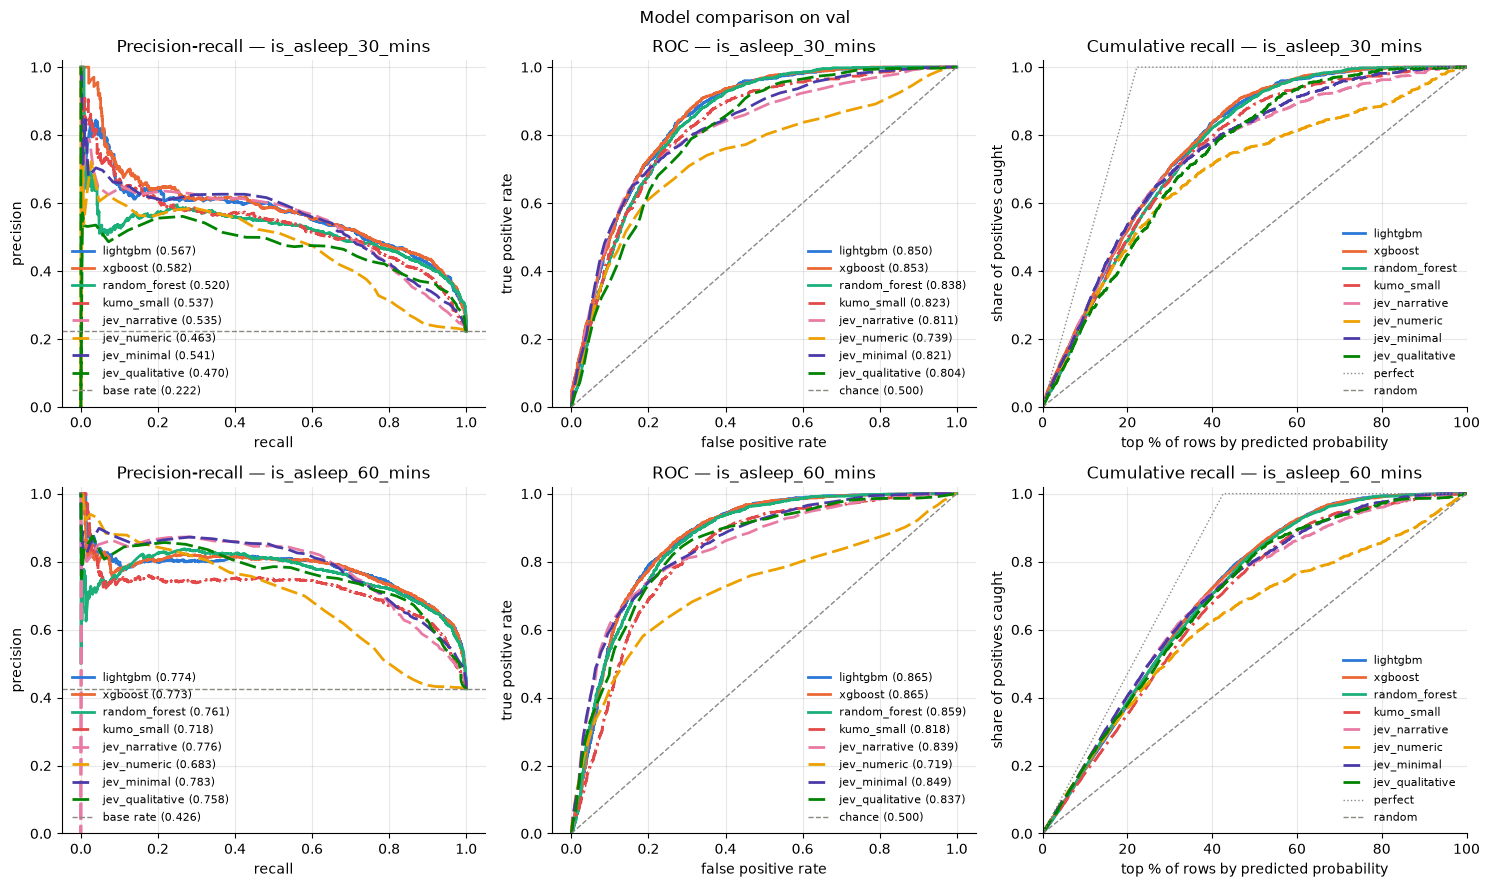

In [4]:
val.plot_performance();

In [5]:
val.recall_at_percentiles().round(3)

top 5%  top 10%  top 20%  top 30%  top 50%
label             model                                                      
is_asleep_30_mins lightgbm          0.137    0.275    0.519    0.703    0.921
                  xgboost           0.151    0.278    0.519    0.704    0.925
                  random_forest     0.124    0.263    0.488    0.671    0.912
                  kumo_small        0.144    0.258    0.495    0.667    0.890
                  jev_narrative     0.139    0.282    0.532    0.685    0.840
                  jev_numeric       0.133    0.263    0.467    0.618    0.767
                  jev_minimal       0.142    0.277    0.537    0.683    0.849
                  jev_qualitative   0.116    0.251    0.448    0.638    0.856
is_asleep_60_mins lightgbm          0.094    0.189    0.379    0.567    0.836
                  xgboost           0.090    0.189    0.381    0.566    0.837
                  random_forest     0.088    0.193    0.387    0.560    0.828
                  kumo_small        0.088    0.178    0.351    0.525    0.791
                  jev_narrative     0.099    0.204    0.404    0.584    0.798
                  jev_numeric       0.104    0.199    0.370    0.512    0.697
                  jev_minimal       0.099    0.202    0.404    0.580    0.803
                  jev_qualitative   0.098    0.201    0.379    0.551    0.821

### Is Kumo's gap to XGBoost real?

Paired bootstrap over whole baby-days, as in `04`. The `gap` columns are each model minus XGBoost on the same resampled days: an interval that excludes 0 is a difference the data supports.

In [6]:
headline_val = [p for (_, name), p in val.predictions.items() if name in ("xgboost", "kumo_small", "jev_minimal")]
bootstrap_by_day(headline_val, baby_days("val"), reference="xgboost")[
    ["value", "ci_low", "ci_high", "gap_vs_xgboost", "gap_ci_low", "gap_ci_high"]
].round(3)

value  ci_low  ci_high  gap_vs_xgboost  \
label             metric  model                                                 
is_asleep_30_mins brier   jev_minimal  0.146   0.140    0.152           0.010   
                          kumo_small   0.259   0.244    0.276           0.123   
                          xgboost      0.136   0.128    0.144           0.000   
                  pr_auc  jev_minimal  0.541   0.507    0.576          -0.041   
                          kumo_small   0.537   0.492    0.584          -0.045   
                          xgboost      0.582   0.546    0.621           0.000   
                  roc_auc jev_minimal  0.821   0.805    0.839          -0.032   
                          kumo_small   0.823   0.806    0.841          -0.029   
                          xgboost      0.853   0.838    0.868           0.000   
is_asleep_60_mins brier   jev_minimal  0.171   0.165    0.176           0.008   
                          kumo_small   0.239   0.221    0.256           0.076   
                          xgboost      0.163   0.152    0.174           0.000   
                  pr_auc  jev_minimal  0.783   0.753    0.811           0.009   
                          kumo_small   0.718   0.680    0.758          -0.056   
                          xgboost      0.773   0.741    0.807           0.000   
                  roc_auc jev_minimal  0.849   0.832    0.866          -0.017   
                          kumo_small   0.818   0.799    0.839          -0.047   
                          xgboost      0.865   0.850    0.882           0.000   

                                       gap_ci_low  gap_ci_high  
label             metric  model                                 
is_asleep_30_mins brier   jev_minimal       0.002        0.019  
                          kumo_small        0.106        0.139  
                          xgboost           0.000        0.000  
                  pr_auc  jev_minimal      -0.088        0.006  
                          kumo_small       -0.082       -0.009  
                          xgboost           0.000        0.000  
                  roc_auc jev_minimal      -0.049       -0.014  
                          kumo_small       -0.044       -0.015  
                          xgboost           0.000        0.000  
is_asleep_60_mins brier   jev_minimal      -0.004        0.019  
                          kumo_small        0.062        0.089  
                          xgboost           0.000        0.000  
                  pr_auc  jev_minimal      -0.031        0.055  
                          kumo_small       -0.090       -0.021  
                          xgboost           0.000        0.000  
                  roc_auc jev_minimal      -0.036        0.003  
                          kumo_small       -0.063       -0.030  
                          xgboost           0.000        0.000

## Stage 2: `test`

The `04` line-up plus Kumo, with both contexts. XGBoost and Jev are rebuilt exactly as in `04`: the same untuned defaults, and Jev's `minimal` layout from cache.

In [7]:
test = df[df[SPLIT] == "test"]

# XGBoost on train only, and refit on train + val (val relabelled as train).
comparison = Comparison.run(df, kinds=["xgboost"], split="test")
df_train_val = df.copy()
df_train_val[SPLIT] = df_train_val[SPLIT].replace({"val": "train"})
assert (df_train_val[SPLIT] == "test").equals(df[SPLIT] == "test")
refit = Comparison.run(df_train_val, kinds=["xgboost"], split="test")
refit_preds = [p.model_copy(update={"name": "xgboost_train_val"}) for p in refit.predictions.values()]

jev_test = list((await JevModel(spec=JevSpec(layout="minimal")).predict(df, "test")).values())

kumo_test = list(kumo.predict(df, "test").values())
kumo_train_val_test = list(kumo_train_val.predict(df, "test").values())

comparison = comparison.with_predictions(refit_preds + kumo_test + kumo_train_val_test + jev_test)
comparison.metrics().round(3)

split  rows  base_rate  pr_auc  \
label             model                                                 
is_asleep_30_mins xgboost               test  4232      0.203   0.482   
                  xgboost_train_val     test  4232      0.203   0.771   
                  kumo_small            test  4232      0.203   0.431   
                  kumo_small_train_val  test  4232      0.203   0.757   
                  jev_minimal           test  4232      0.203   0.509   
is_asleep_60_mins xgboost               test  4232      0.395   0.716   
                  xgboost_train_val     test  4232      0.395   0.906   
                  kumo_small            test  4232      0.395   0.608   
                  kumo_small_train_val  test  4232      0.395   0.858   
                  jev_minimal           test  4232      0.395   0.747   

                                        roc_auc  brier  brier_base_rate  \
label             model                                                   
is_asleep_30_mins xgboost                 0.827  0.152            0.162   
                  xgboost_train_val       0.928  0.085            0.162   
                  kumo_small              0.794  0.280            0.162   
                  kumo_small_train_val    0.925  0.124            0.162   
                  jev_minimal             0.830  0.138            0.162   
is_asleep_60_mins xgboost                 0.838  0.193            0.239   
                  xgboost_train_val       0.941  0.096            0.239   
                  kumo_small              0.774  0.278            0.239   
                  kumo_small_train_val    0.920  0.125            0.239   
                  jev_minimal             0.843  0.168            0.239   

                                        mean_predicted  
label             model                                 
is_asleep_30_mins xgboost                        0.322  
                  xgboost_train_val              0.223  
                  kumo_small                     0.579  
                  kumo_small_train_val           0.373  
                  jev_minimal                    0.318  
is_asleep_60_mins xgboost                        0.564  
                  xgboost_train_val              0.428  
                  kumo_small                     0.698  
                  kumo_small_train_val           0.494  
                  jev_minimal                    0.455

### With confidence intervals, against the refit XGBoost

In [8]:
ci = bootstrap_by_day(list(comparison.predictions.values()), baby_days("test"), reference="xgboost_train_val")
ci[["value", "ci_low", "ci_high", "gap_vs_xgboost_train_val", "gap_ci_low", "gap_ci_high"]].round(3)

value  ci_low  ci_high  \
label             metric  model                                          
is_asleep_30_mins brier   jev_minimal           0.138   0.132    0.143   
                          kumo_small            0.280   0.270    0.291   
                          kumo_small_train_val  0.124   0.110    0.141   
                          xgboost               0.152   0.143    0.160   
                          xgboost_train_val     0.085   0.076    0.094   
                  pr_auc  jev_minimal           0.509   0.469    0.547   
                          kumo_small            0.431   0.390    0.480   
                          kumo_small_train_val  0.757   0.710    0.805   
                          xgboost               0.482   0.438    0.532   
                          xgboost_train_val     0.771   0.735    0.808   
                  roc_auc jev_minimal           0.830   0.813    0.848   
                          kumo_small            0.794   0.772    0.819   
                          kumo_small_train_val  0.925   0.906    0.941   
                          xgboost               0.827   0.809    0.844   
                          xgboost_train_val     0.928   0.914    0.942   
is_asleep_60_mins brier   jev_minimal           0.168   0.162    0.175   
                          kumo_small            0.278   0.263    0.291   
                          kumo_small_train_val  0.125   0.110    0.140   
                          xgboost               0.193   0.180    0.205   
                          xgboost_train_val     0.096   0.084    0.107   
                  pr_auc  jev_minimal           0.747   0.711    0.780   
                          kumo_small            0.608   0.568    0.656   
                          kumo_small_train_val  0.858   0.812    0.897   
                          xgboost               0.716   0.679    0.756   
                          xgboost_train_val     0.906   0.887    0.927   
                  roc_auc jev_minimal           0.843   0.824    0.861   
                          kumo_small            0.774   0.752    0.797   
                          kumo_small_train_val  0.920   0.901    0.938   
                          xgboost               0.838   0.821    0.857   
                          xgboost_train_val     0.941   0.928    0.954   

                                                gap_vs_xgboost_train_val  \
label             metric  model                                            
is_asleep_30_mins brier   jev_minimal                              0.053   
                          kumo_small                               0.195   
                          kumo_small_train_val                     0.039   
                          xgboost                                  0.067   
                          xgboost_train_val                        0.000   
                  pr_auc  jev_minimal                             -0.261   
                          kumo_small                              -0.339   
                          kumo_small_train_val                    -0.014   
                          xgboost                                 -0.289   
                          xgboost_train_val                        0.000   
                  roc_auc jev_minimal                             -0.098   
                          kumo_small                              -0.134   
                          kumo_small_train_val                    -0.004   
                          xgboost                                 -0.101   
                          xgboost_train_val                        0.000   
is_asleep_60_mins brier   jev_minimal                              0.072   
                          kumo_small                               0.182   
                          kumo_small_train_val                     0.029   
                          xgboost                                  0.097   
                          xgboost_train_val                        0.000   
       

### Like for like: context = `train` only

Kumo and XGBoost that have both only seen `train`, the pair that matches the `val` stage.

In [9]:
like_for_like = [p for (_, name), p in comparison.predictions.items() if name in ("xgboost", "kumo_small", "jev_minimal")]
bootstrap_by_day(like_for_like, baby_days("test"), reference="xgboost").drop("xgboost", level="model")[
    ["value", "gap_vs_xgboost", "gap_ci_low", "gap_ci_high"]
].round(3)

value  gap_vs_xgboost  gap_ci_low  \
label             metric  model                                            
is_asleep_30_mins brier   jev_minimal  0.138          -0.014      -0.024   
                          kumo_small   0.280           0.128       0.118   
                  pr_auc  jev_minimal  0.509           0.027      -0.037   
                          kumo_small   0.431          -0.050      -0.083   
                  roc_auc jev_minimal  0.830           0.003      -0.017   
                          kumo_small   0.794          -0.033      -0.049   
is_asleep_60_mins brier   jev_minimal  0.168          -0.025      -0.036   
                          kumo_small   0.278           0.085       0.075   
                  pr_auc  jev_minimal  0.747           0.031      -0.012   
                          kumo_small   0.608          -0.108      -0.139   
                  roc_auc jev_minimal  0.843           0.005      -0.015   
                          kumo_small   0.774          -0.064      -0.079   

                                       gap_ci_high  
label             metric  model                     
is_asleep_30_mins brier   jev_minimal       -0.004  
                          kumo_small         0.138  
                  pr_auc  jev_minimal        0.088  
                          kumo_small        -0.019  
                  roc_auc jev_minimal        0.024  
                          kumo_small        -0.016  
is_asleep_60_mins brier   jev_minimal       -0.013  
                          kumo_small         0.094  
                  pr_auc  jev_minimal        0.071  
                          kumo_small        -0.074  
                  roc_auc jev_minimal        0.027  
                          kumo_small        -0.047

### Curves

The three headline models: refit XGBoost (solid), Kumo with the train + val context (dash-dot) and Jev (dashed). The train-only variants share their family's colour, so they're left to the tables.

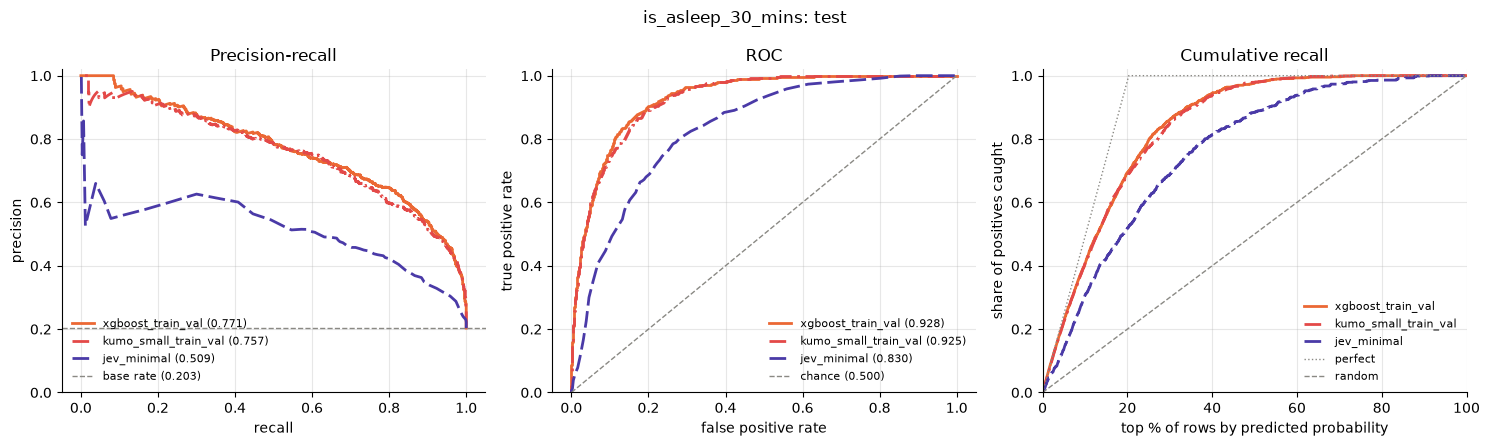

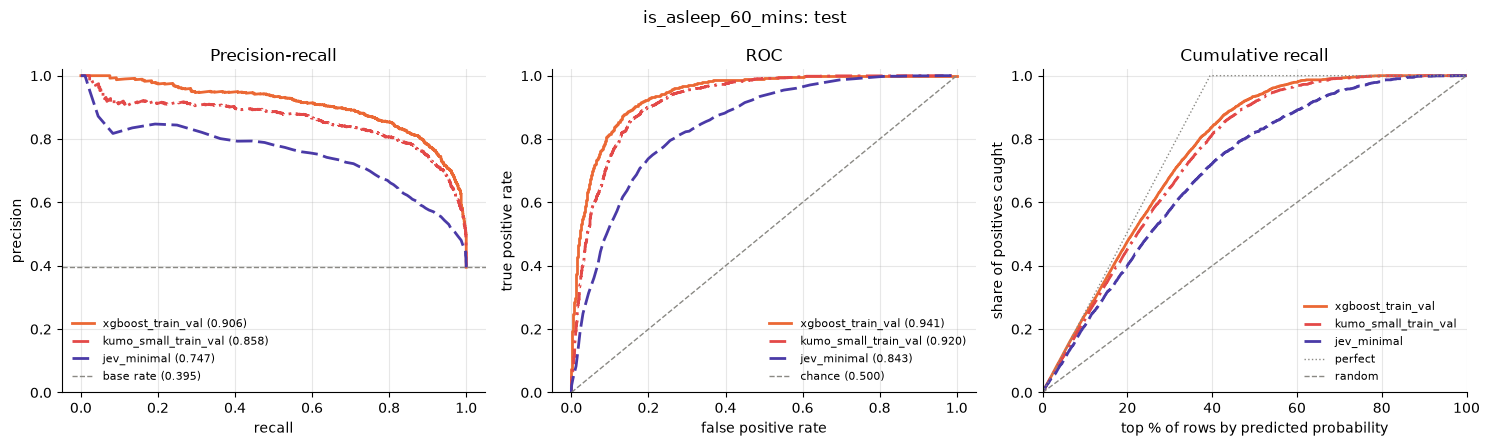

In [10]:
for label in LABELS:
    trio = [comparison.predictions[(label, name)] for name in ("xgboost_train_val", "kumo_small_train_val", "jev_minimal")]
    plot_performance(trio, title=f"{label}: test")

In [11]:
comparison.recall_at_percentiles().round(3)

top 5%  top 10%  top 20%  top 30%  \
label             model                                                     
is_asleep_30_mins xgboost                0.138    0.280    0.487    0.656   
                  xgboost_train_val      0.223    0.405    0.693    0.860   
                  kumo_small             0.103    0.230    0.463    0.620   
                  kumo_small_train_val   0.222    0.407    0.683    0.849   
                  jev_minimal            0.136    0.306    0.517    0.687   
is_asleep_60_mins xgboost                0.103    0.190    0.382    0.554   
                  xgboost_train_val      0.125    0.245    0.477    0.680   
                  kumo_small             0.067    0.150    0.341    0.494   
                  kumo_small_train_val   0.115    0.230    0.452    0.646   
                  jev_minimal            0.102    0.211    0.400    0.576   

                                        top 50%  
label             model                          
is_asleep_30_mins xgboost                 0.908  
                  xgboost_train_val       0.978  
                  kumo_small              0.859  
                  kumo_small_train_val    0.979  
                  jev_minimal             0.885  
is_asleep_60_mins xgboost                 0.819  
                  xgboost_train_val       0.934  
                  kumo_small              0.745  
                  kumo_small_train_val    0.916  
                  jev_minimal             0.821

### By baby

Imogen is the baby this is for going forward. Her `test` stretch is only about 17 days, so expect wide swings.

In [12]:
by_baby = []
for (label, name), pred in comparison.predictions.items():
    for baby in ["Ember", "Imogen"]:
        mask = (test["baby_name"] == baby).to_numpy()
        sub = Predictions(name=name, label=label, split="test", y_true=pred.y_true[mask], p=pred.p[mask])
        row = metrics_table([sub]).reset_index()
        row.insert(0, "baby", baby)
        by_baby.append(row)
(
    pd.concat(by_baby)
    .set_index(["baby", "label", "model"])[["rows", "base_rate", "pr_auc", "roc_auc", "brier", "brier_base_rate", "mean_predicted"]]
    .sort_index().round(3)
)

rows  base_rate  pr_auc  \
baby   label             model                                           
Ember  is_asleep_30_mins jev_minimal           2450      0.180   0.429   
                         kumo_small            2450      0.180   0.467   
                         kumo_small_train_val  2450      0.180   0.859   
                         xgboost               2450      0.180   0.461   
                         xgboost_train_val     2450      0.180   0.839   
       is_asleep_60_mins jev_minimal           2450      0.360   0.645   
                         kumo_small            2450      0.360   0.682   
                         kumo_small_train_val  2450      0.360   0.931   
                         xgboost               2450      0.360   0.716   
                         xgboost_train_val     2450      0.360   0.940   
Imogen is_asleep_30_mins jev_minimal           1782      0.235   0.582   
                         kumo_small            1782      0.235   0.439   
                         kumo_small_train_val  1782      0.235   0.629   
                         xgboost               1782      0.235   0.516   
                         xgboost_train_val     1782      0.235   0.676   
       is_asleep_60_mins jev_minimal           1782      0.443   0.847   
                         kumo_small            1782      0.443   0.616   
                         kumo_small_train_val  1782      0.443   0.759   
                         xgboost               1782      0.443   0.728   
                         xgboost_train_val     1782      0.443   0.852   

                                               roc_auc  brier  \
baby   label             model                                  
Ember  is_asleep_30_mins jev_minimal             0.831  0.134   
                         kumo_small              0.853  0.295   
                         kumo_small_train_val    0.967  0.078   
                         xgboost                 0.838  0.151   
                         xgboost_train_val       0.959  0.062   
       is_asleep_60_mins jev_minimal             0.822  0.172   
                         kumo_small              0.847  0.302   
                         kumo_small_train_val    0.964  0.079   
                         xgboost                 0.853  0.194   
                         xgboost_train_val       0.969  0.066   
Imogen is_asleep_30_mins jev_minimal             0.817  0.143   
                         kumo_small              0.764  0.259   
                         kumo_small_train_val    0.847  0.187   
                         xgboost                 0.819  0.153   
                         xgboost_train_val       0.877  0.117   
       is_asleep_60_mins jev_minimal             0.868  0.164   
                         kumo_small              0.753  0.245   
                         kumo_small_train_val    0.839  0.188   
                         xgboost                 0.820  0.191   
                         xgboost_train_val       0.886  0.138   

                                               brier_base_rate  mean_predicted  
baby   label             model                                                  
Ember  is_asleep_30_mins jev_minimal                     0.148           0.303  
                         kumo_small                      0.148           0.596  
                         kumo_small_train_val            0.148           0.304  
                         xgboost                         0.148           0.323  
                         xgboost_train_val               0.148           0.191  
       is_asleep_60_mins jev_minimal                     0.230           0.437  
                         kumo_small                      0.230           0.724  
                         kumo_small_train_val            0.230           0.417  
                         xgboost                         0.230           0.552  
                         xgboost_train_val               0.230           0.379  
Imogen is_aslee

## Findings

Kumo here is the `small` model with 1 ensemble member, on CPU (4 members crashed this 16 GB laptop mid-fit). Larger models and more members may do better; see "What next".

**1. With the same `train` context, Kumo ranks a little behind XGBoost, and no better than zero-shot Jev.** On `val`, PR-AUC is 0.537 against XGBoost's 0.582 on 30 minutes, and 0.718 against 0.773 on 60. Both gaps' intervals exclude zero. On 30 minutes it's level with `jev_minimal` (0.541); on 60 it's behind it (0.783). On `test`, like for like, it's the weakest of the three: PR-AUC 0.431 / 0.608 against XGBoost's 0.482 / 0.716 and Jev's 0.509 / 0.747.

**2. Its probabilities are badly inflated, and that's a data shift, not a bug.** On `val` it predicts a mean of 0.56 where the true rate is 0.22. Its Brier score (0.259) is *worse than always predicting the base rate* (0.173). On synthetic data it was calibrated to within a point, so the wiring is fine. The split is forward in time: the `train` context comes from younger babies with a higher sleep rate (33% vs 22%), and the query rows lie outside it (older ages, fewer naps). An in-context model trusts its context, and NVIDIA's model card warns about exactly this. Don't use its raw probabilities without recalibrating.

**3. Give it recent rows and it catches up with the refit XGBoost, with no training at all.** Adding `val` to the context lifts `test` PR-AUC from 0.431 to **0.757** on 30 minutes. The refit XGBoost scores 0.771, and the gap interval (−0.049 to +0.023) includes zero, so on this data the two are tied. ROC-AUC is tied too (0.925 vs 0.928). On 60 minutes it's close but significantly behind: 0.858 vs 0.906, interval −0.082 to −0.018. Brier stays worse (0.124 vs 0.085 on 30 minutes), still over-predicting (0.37 vs 0.20).

**4. It's recency again.** `04` found that recent data teaches the current nap times. Kumo shows the same thing without fitting anything: the same weights, handed the newest weeks, jump from worst to near best.

**5. By baby, it's strongest on Ember and weaker on Imogen, the baby this is for.** For Ember, Kumo with `train` + `val` context beats the refit XGBoost on 30 minutes (PR-AUC 0.859 vs 0.839). For Imogen it's behind: 0.629 vs 0.676 on 30 minutes, and 0.759 vs 0.852 on 60, where zero-shot Jev (0.847) also does better. Imogen's `test` stretch is only about 17 days, so these are noisy.

**A caution:** `test` was already read in `04`. Kumo's settings were fixed before running it (library defaults, small, 1 member), and nothing was changed after, but it is a second look at the same `test` rows.

**What next**
- **More capacity, on a GPU:** `medium` / `large` with 4–8 members. The library is built for CUDA, where this whole notebook would take seconds.
- **Context choice is the real lever:** try a context of only the most recent weeks (or `train` + `val` with older rows dropped), chosen on `val` before touching `test` again.
- **Fix the shift, not just the symptom:** try dropping the age columns, which put every query row outside the context's range. If the probabilities matter (e.g. showing "72% likely to nap"), recalibrate on `val` with isotonic or Platt scaling.